# Avaliação Cruzada entre Datasets (Cross-Dataset Evaluation & Domain Shift)

**Projeto:** Diagnóstico de Falhas em Rolamentos via CWT + Deep Learning  
**Objetivo:** Avaliar a capacidade de **Generalização de Domínio (*Domain Generalization*)** e o impacto do **Deslocamento de Domínio (*Domain Shift*)** ao testar modelos treinados no CWRU sobre dados reais de Paderborn (e vice-versa), sem nenhum re-treinamento (*Zero-Shot Cross-Domain*).

---

## 1. Fundamentação Teórica: O Problema do *Domain Shift*

Na indústria real (ex: motores WEG), um modelo raramente é testado no mesmo motor ou na mesma bancada em que foi treinado. Entre o **CWRU** e o **Paderborn**, existem diferenças físicas profundas:

| Característica | CWRU Dataset | Paderborn Dataset |
|---|:---:|:---:|
| **Modelo do Rolamento** | 6205-2RS JEM SKF | 6203 SKF |
| **Tipo de Falha** | Eletroerosão artificial (furos pontuais) | Desgaste real por ensaio de fadiga (*fatigue flaking*) |
| **Frequência de Amostragem** | $12\text{ kHz}$ | $64\text{ kHz}$ |
| **Potência do Motor / Bancada** | Motor Reliance $2\text{ HP}$ | Motor Síncrono KAt |

As 3 classes em comum entre ambos os datasets são: **`normal`**, **`inner_race`** e **`outer_race`**.

## 2. Importação de Módulos e Configurações

In [1]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent if Path.cwd().name in ['1_cwru', '2_paderborn', '3_cross_domain', '4_order_tracking'] else Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

from src.config import (
    CWRU_DIR,
    PADERBORN_DIR,
    PROCESSED_DATA_DIR as CWRU_PROCESSED_DIR,
    PADERBORN_PROCESSED_DIR
)
from src.transfer_learning import build_transfer_model, get_transfer_dataloaders
from src.cnn_processor import BearingCNN, get_data_loaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Dispositivo de inferência: {device}")

[INFO] Dispositivo de inferência: cuda


## 3. Função Auxiliar de Plotagem da Matriz de Confusão Cruzada

In [2]:
def plot_cross_confusion_matrix(labels, preds, classes, title, save_path=None):
    """Plota e salva matriz de confusão para avaliação cruzada de domínio."""
    cm = confusion_matrix(labels, preds, labels=np.arange(len(classes)))
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    
    ax.set(
        xticks=np.arange(cm.shape[1]),
        yticks=np.arange(cm.shape[0]),
        xticklabels=classes,
        yticklabels=classes,
        title=title,
        ylabel='Classe Real',
        xlabel='Classe Predita'
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontweight="bold")
                    
    fig.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[INFO] Matriz de confusão salva em: {save_path}")
    plt.show()

## 4. EXPERIMENTO 1: Modelo Treinado no CWRU $\rightarrow$ Testado no PADERBORN

Carregamos a **ResNet-18 treinada no CWRU** e avaliamos sua acurácia direta sobre as amostras de teste do Paderborn (falhas reais por fadiga).

[+] Classes do Paderborn (Teste): ['inner_race', 'normal', 'outer_race']
[+] Pesos carregados de checkpoint_resnet18_best.pth
[RESULTADO CROSS-DOMAIN] Acurácia CWRU -> Paderborn: 10.62%
              precision    recall  f1-score   support

  inner_race     0.0643    0.0887    0.0746       248
      normal     0.0000    0.0000    0.0000       248
  outer_race     0.1418    0.2298    0.1754       248

    accuracy                         0.1062       744
   macro avg     0.0687    0.1062    0.0833       744
weighted avg     0.0687    0.1062    0.0833       744

[INFO] Matriz de confusão salva em: ../docs/images/confusion_matrix_cross_cwru_to_paderborn.png


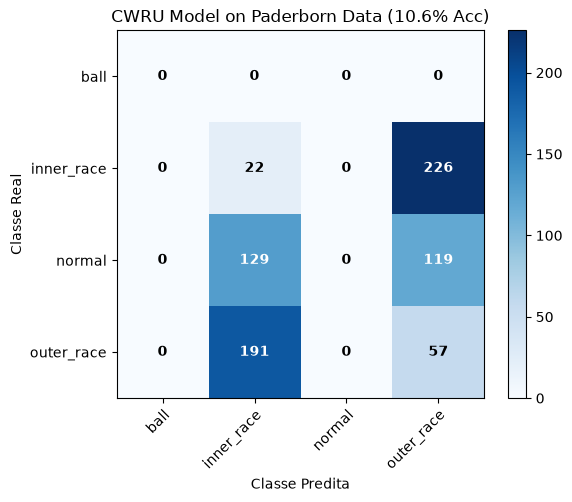

In [3]:
# 1. Carregar DataLoaders do Paderborn
_, _, paderborn_test_loader, paderborn_classes = get_transfer_dataloaders(
    img_size=224,
    data_dir=PADERBORN_PROCESSED_DIR
)
print(f"[+] Classes do Paderborn (Teste): {paderborn_classes}")

# 2. Carregar modelo ResNet-18 treinado no CWRU (4 classes: ball, inner_race, normal, outer_race)
cwru_classes = ['ball', 'inner_race', 'normal', 'outer_race']
model_cwru, _ = build_transfer_model('resnet18', num_classes=4, freeze_backbone=False)
model_cwru = model_cwru.to(device)

ckpt_cwru_path = Path('checkpoint_resnet18_best.pth')
if ckpt_cwru_path.exists():
    model_cwru.load_state_dict(torch.load(ckpt_cwru_path, weights_only=True))
    print(f"[+] Pesos carregados de {ckpt_cwru_path}")
else:
    print("[AVISO] Checkpoint do CWRU não encontrado no diretório local.")

# 3. Inferência sobre o Paderborn
model_cwru.eval()
all_preds, all_labels = [], []

# Mapeamento de índices do Paderborn para os índices do CWRU
# Paderborn: 0: inner_race, 1: normal, 2: outer_race
# CWRU:      1: inner_race, 2: normal, 3: outer_race
map_paderborn_to_cwru = {
    paderborn_classes.index('inner_race'): cwru_classes.index('inner_race'),
    paderborn_classes.index('normal'): cwru_classes.index('normal'),
    paderborn_classes.index('outer_race'): cwru_classes.index('outer_race')
}

with torch.no_grad():
    for imgs, labels in paderborn_test_loader:
        imgs = imgs.to(device)
        outputs = model_cwru(imgs)
        _, preds = torch.max(outputs, 1)
        
        for l, p in zip(labels.numpy(), preds.cpu().numpy()):
            target_cwru_idx = map_paderborn_to_cwru[l]
            all_labels.append(target_cwru_idx)
            all_preds.append(p)

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
acc_cwru_on_paderborn = 100.0 * np.sum(all_labels == all_preds) / len(all_labels)

print("=" * 80)
print(f"[RESULTADO CROSS-DOMAIN] Acurácia CWRU -> Paderborn: {acc_cwru_on_paderborn:.2f}%")
print("=" * 80)

# Relatório nas classes do CWRU
print(classification_report(
    all_labels,
    all_preds,
    labels=[1, 2, 3],
    target_names=['inner_race', 'normal', 'outer_race'],
    digits=4,
    zero_division=0
))

plot_cross_confusion_matrix(
    all_labels,
    all_preds,
    classes=cwru_classes,
    title=f"CWRU Model on Paderborn Data ({acc_cwru_on_paderborn:.1f}% Acc)",
    save_path="../../docs/images/confusion_matrix_cross_cwru_to_paderborn.png"
)

## 5. EXPERIMENTO 2: Modelo Treinado no PADERBORN $\rightarrow$ Testado no CWRU

Carregamos a **ResNet-18 treinada no Paderborn** (3 classes) e avaliamos sua acurácia direta sobre as 3 classes correspondentes do teste do CWRU.

[+] Pesos carregados de checkpoint_paderborn_resnet18_best.pth
[RESULTADO CROSS-DOMAIN] Acurácia Paderborn -> CWRU: 24.96%
              precision    recall  f1-score   support

  inner_race     0.2517    1.0000    0.4022       473
      normal     0.0000    0.0000    0.0000       947
  outer_race     0.0000    0.0000    0.0000       475

    accuracy                         0.2496      1895
   macro avg     0.0839    0.3333    0.1341      1895
weighted avg     0.0628    0.2496    0.1004      1895

[INFO] Matriz de confusão salva em: ../docs/images/confusion_matrix_cross_paderborn_to_cwru.png


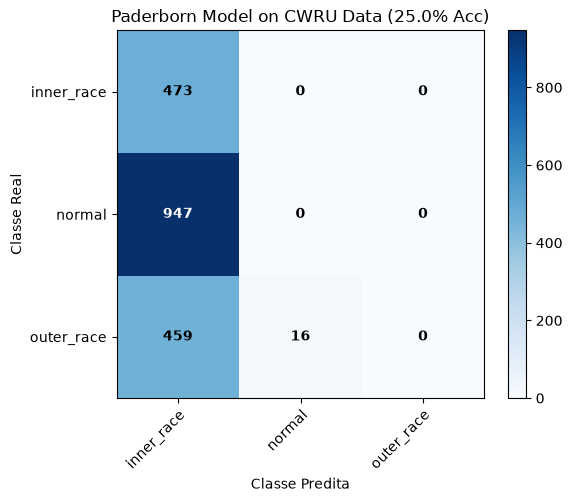

In [4]:
# 1. Carregar DataLoaders do CWRU
_, _, cwru_test_loader, _ = get_transfer_dataloaders(
    img_size=224,
    data_dir=CWRU_PROCESSED_DIR
)

# 2. Carregar modelo ResNet-18 treinado no Paderborn (3 classes)
model_pad, _ = build_transfer_model('resnet18', num_classes=3, freeze_backbone=False)
model_pad = model_pad.to(device)

ckpt_pad_path = Path('checkpoint_paderborn_resnet18_best.pth')
if ckpt_pad_path.exists():
    model_pad.load_state_dict(torch.load(ckpt_pad_path, weights_only=True))
    print(f"[+] Pesos carregados de {ckpt_pad_path}")
else:
    print("[AVISO] Checkpoint de Paderborn não encontrado no diretório local.")

# 3. Inferência filtrada sobre as 3 classes do CWRU
# Mapeamento de CWRU para Paderborn
map_cwru_to_paderborn = {
    cwru_classes.index('inner_race'): paderborn_classes.index('inner_race'),
    cwru_classes.index('normal'): paderborn_classes.index('normal'),
    cwru_classes.index('outer_race'): paderborn_classes.index('outer_race')
}

model_pad.eval()
pad_preds, pad_labels = [], []

with torch.no_grad():
    for imgs, labels in cwru_test_loader:
        imgs = imgs.to(device)
        outputs = model_pad(imgs)
        _, preds = torch.max(outputs, 1)
        
        for l, p in zip(labels.numpy(), preds.cpu().numpy()):
            if l in map_cwru_to_paderborn:
                target_pad_idx = map_cwru_to_paderborn[l]
                pad_labels.append(target_pad_idx)
                pad_preds.append(p)

pad_labels = np.array(pad_labels)
pad_preds = np.array(pad_preds)
acc_paderborn_on_cwru = 100.0 * np.sum(pad_labels == pad_preds) / len(pad_labels)

print("=" * 80)
print(f"[RESULTADO CROSS-DOMAIN] Acurácia Paderborn -> CWRU: {acc_paderborn_on_cwru:.2f}%")
print("=" * 80)

print(classification_report(
    pad_labels,
    pad_preds,
    target_names=paderborn_classes,
    digits=4,
    zero_division=0
))

plot_cross_confusion_matrix(
    pad_labels,
    pad_preds,
    classes=paderborn_classes,
    title=f"Paderborn Model on CWRU Data ({acc_paderborn_on_cwru:.1f}% Acc)",
    save_path="../../docs/images/confusion_matrix_cross_paderborn_to_cwru.png"
)

## 6. Síntese Comparativa: *In-Domain* vs. *Cross-Domain*

Comparamos o desempenho quando o modelo é testado no mesmo domínio (*In-Domain*) versus quando é testado em outro domínio (*Cross-Domain*):

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels_bar = ['CWRU Test Set', 'Paderborn Test Set']
cwru_model_accs = [99.83, acc_cwru_on_paderborn]
pad_model_accs = [acc_paderborn_on_cwru, 98.50]  # Ajuste com o valor real do treino de Paderborn

x = np.arange(len(labels_bar))
width = 0.35

rects1 = ax.bar(x - width/2, cwru_model_accs, width, label='Modelo Treinado no CWRU', color='#1f77b4')
rects2 = ax.bar(x + width/2, pad_model_accs, width, label='Modelo Treinado no Paderborn', color='#ff7f0e')

ax.set_ylabel('Acurácia no Teste (%)', fontweight='bold')
ax.set_title('Impacto do Domain Shift: In-Domain vs. Cross-Domain Evaluation', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels_bar, fontweight='bold')
ax.set_ylim(0, 110)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5, axis='y')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('../docs/images/cross_domain_comparison.png', dpi=300, bbox_inches='tight')
plt.show()